Analisis preliminar

## Tratamiendo de datos

In [1]:
#pip install pandas pyxlsb

In [2]:
import pandas as pd

# Ruta del archivo
ruta = r"C:\Users\preci\TRANSPORTES C MORALES C SA de CV\Tesorería y Finanzas Treher - Finanzas Grupo Treher\01.Diarios\PRECIOS COMPETENCIA 2026.xlsb"

# Leer la hoja DB (encabezados en la fila 1)
df = pd.read_excel(
    ruta,
    sheet_name="DB",
    engine="pyxlsb",
    header=0
)


In [3]:
# -------------------------
# 1. Copia de seguridad
# -------------------------
df_clean = df.copy()

# -------------------------
# 2. Normalizar nombres de columnas
# -------------------------
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
)

# -------------------------
# 3. Eliminar columnas basura (ya normalizadas)
# -------------------------
cols_to_drop = [
    col for col in df_clean.columns
    if col.startswith("Unnamed")
    or col.startswith("*_")
    or col == "Columna1"
]

df_clean.drop(columns=cols_to_drop, inplace=True, errors="ignore")

# -------------------------
# 4. Eliminar fecha inválida (serial 0 de Excel)
# -------------------------
df_clean = df_clean[df_clean["Fecha"] != 0].copy()

# -------------------------
# 5. Convertir Fecha (Excel → datetime)
# -------------------------
df_clean["Fecha"] = pd.to_datetime(
    df_clean["Fecha"],
    origin="1899-12-30",
    unit="D"
)

# -------------------------
# 6. Filtrar solo permisos CRE de interés
# -------------------------
permisos_validos = [
    "PL/12856/EXP/ES/2015",
    "PL/19215/EXP/ES/2016",
    "PL/3086/EXP/ES/2015",
    "PL/9330/EXP/ES/2015",
    "PL/1767/EXP/ES/2015",
    "PL/2966/EXP/ES/2015",
    "PL/1900/EXP/ES/2015",
    "PL/2209/EXP/ES/2015",
    "PL/2616/EXP/ES/2015",
    "PL/2027/EXP/ES/2015",
    "PL/19259/EXP/ES/2016",
    "PL/5210/EXP/ES/2015",
    "PL/1731/EXP/ES/2015",
    "PL/22399/EXP/ES/2019",
    "PL/10078/EXP/ES/2015",
    "PL/6932/EXP/ES/2015",
    "PL/20583/EXP/ES/2017",
    "PL/1417/EXP/ES/2015",
    "PL/1278/EXP/ES/2015",
    "PL/12677/EXP/ES/2015",
    "PL/20126/EXP/ES/2017",
    "PL/22827/EXP/ES/2019",
    "PL/19078/EXP/ES/2016",
    "PL/18967/EXP/ES/2016",
    "PL/2712/EXP/ES/2015",
    "PL/6407/EXP/ES/2015",
    "PL/1446/EXP/ES/2015",
    "PL/9370/EXP/ES/2015",
    "PL/4394/EXP/ES/2015",
    "PL/4401/EXP/ES/2015",
    "PL/1689/EXP/ES/2015",
    "PL/24614/EXP/ES/2022",
    "PL/24156/EXP/ES/2022",
    "PL/19278/EXP/ES/2016",
    "PL/22402/EXP/ES/2019",
    "PL/6909/EXP/ES/2015",
    "PL/19264/EXP/ES/2016",
    "PL/6187/EXP/ES/2015",
    "PL/5742/EXP/ES/2015",
    "PL/11327/EXP/ES/2015",
    "PL/11271/EXP/ES/2015",
    "PL/3301/EXP/ES/2015",
    "PL/5992/EXP/ES/2015",
    "PL/11423/EXP/ES/2015"
]

df_clean = df_clean[df_clean["Permiso_CRE"].isin(permisos_validos)].copy()




In [4]:
import numpy as np
# Rango completo de fechas
rango_fechas = pd.date_range(
    start="2025-11-01",
    end=df_clean["Fecha"].max(),
    freq="D"
)
estaciones = df_clean["Permiso_CRE"].unique()

#Crear base estación–fecha
calendario = pd.MultiIndex.from_product(
    [estaciones, rango_fechas],
    names=["Permiso_CRE", "Fecha"]
).to_frame(index=False)

#Unir con tus datos reales
df_full = calendario.merge(
    df_clean,
    on=["Permiso_CRE", "Fecha"],
    how="left"
)
# Asegurar orden lógico estación → fecha
DB = (
    df_full
    .sort_values(["Permiso_CRE", "Fecha"])
    .reset_index(drop=True)
)
# Columnas de precios
cols_precios = ["Regular", "Premium", "Diesel"]

# Reemplazar 0 por NaN solo en precios
DB[cols_precios] = DB[cols_precios].replace(0, np.nan)



In [5]:
DB.head()

,Permiso_CRE,Fecha,Estación,Entidad,Municipio,Regular,Premium,Diesel,Marca
0,PL/10078/EXP/ES/2015,2025-11-01,OPERADORA INTERGASOLINERAS S.A. DE C.V.,ESTADO DE MÉXICO,TEOLOYUCAN,23.49,23.99,23.5,Pemex
1,PL/10078/EXP/ES/2015,2025-11-02,OPERADORA INTERGASOLINERAS S.A. DE C.V.,ESTADO DE MÉXICO,TEOLOYUCAN,23.49,23.99,23.5,Pemex
2,PL/10078/EXP/ES/2015,2025-11-03,OPERADORA INTERGASOLINERAS S.A. DE C.V.,ESTADO DE MÉXICO,TEOLOYUCAN,23.49,23.99,23.5,Pemex
3,PL/10078/EXP/ES/2015,2025-11-04,OPERADORA INTERGASOLINERAS S.A. DE C.V.,ESTADO DE MÉXICO,TEOLOYUCAN,23.49,23.99,23.5,Pemex
4,PL/10078/EXP/ES/2015,2025-11-05,OPERADORA INTERGASOLINERAS S.A. DE C.V.,ESTADO DE MÉXICO,TEOLOYUCAN,23.49,23.99,23.5,Pemex


### Diccionario de relaciones

In [6]:
ESTACIONES = {
    # -------------------------
    # ATB 
    # -------------------------
    "PL/12856/EXP/ES/2015": {
        "alias": "ATB",
        "competidores": {
            "PL/22399/EXP/ES/2019": "Porba",
            "PL/10078/EXP/ES/2015": "Intergasolineras",
            "PL/6932/EXP/ES/2015": "Teoloyucan",
            "PL/20583/EXP/ES/2017": "Nuevo Siglo",
            "PL/26174/EXP/ES/2025": "Servicio Moderno"
        }
    },

    # -------------------------
    # ATEPO
    # -------------------------
    "PL/19215/EXP/ES/2016": {
        "alias": "ATEPO",
        "competidores": {
            "PL/1417/EXP/ES/2015": "San Fco"
        }
    },

    # -------------------------
    # AURORA
    # -------------------------
    "PL/3086/EXP/ES/2015": {
        "alias": "AURORA",
        "competidores": {
            "PL/1278/EXP/ES/2015": "Mobil",
            "PL/11327/EXP/ES/2015":"Bellavista",
            "PL/11271/EXP/ES/2015":"Galigas"
        }
    },

    # -------------------------
    # AVE FÉNIX
    # -------------------------
    "PL/9330/EXP/ES/2015": {
        "alias": "AVE_FENIX",
        "competidores": {
            "PL/12677/EXP/ES/2015": "Azulita",
            "PL/20126/EXP/ES/2017": "Pemex",
            "PL/22827/EXP/ES/2019": "PetroJunipero",
            "PL/3301/EXP/ES/2015":"Gasolinera PEMEX",
            "PL/8214/EXP/ES/2015": "MR FILL"
        }
    },

    # -------------------------
    # COMBULUB
    # -------------------------
    "PL/1767/EXP/ES/2015": {
        "alias": "COMBULUB",
        "competidores": {
            "PL/19078/EXP/ES/2016": "Orozco",
            "PL/18967/EXP/ES/2016": "Glama"
        }
    },

    # -------------------------
    # HUEHUETOCA
    # -------------------------
    "PL/2966/EXP/ES/2015": {
        "alias": "HUEHUETOCA",
        "competidores": {
            "PL/2712/EXP/ES/2015": "NR Combustibles",
            "PL/6407/EXP/ES/2015": "Valero Jorobas"
        }
    },

    # -------------------------
    # IXTAZACUALA 
    # -------------------------
    "PL/1900/EXP/ES/2015": {
        "alias": "IXTAZACUALA",
        "competidores": {
            "PL/1446/EXP/ES/2015": "Servifacil",
            "PL/9370/EXP/ES/2015": "Paran"
        }
    },

    # -------------------------
    # QL 
    # -------------------------
    "PL/2209/EXP/ES/2015": {
        "alias": "QL",
        "competidores": {
            "PL/5992/EXP/ES/2015": "Ultra moderno",
            "PL/4394/EXP/ES/2015":"Parador"
        }
    },

    # -------------------------
    # TEOLOYUCAN
    # -------------------------
    "PL/2616/EXP/ES/2015": {
        "alias": "TEOLOYUCAN",
        "competidores": {
            "PL/4401/EXP/ES/2015": "Parador"
        }
    },

    # -------------------------
    # TREHER T 
    # -------------------------
    "PL/2027/EXP/ES/2015": {
        "alias": "TREHER_T",
        "competidores": {
            "PL/1689/EXP/ES/2015": "CID Valero",
            "PL/24614/EXP/ES/2022": "Pemex Nueva",
            "PL/24156/EXP/ES/2022": "Pemex Combu"
        }
    },

    # -------------------------
    # TOREMEX 
    # -------------------------
    "PL/5210/EXP/ES/2015": {
        "alias": "TOREMEX",
        "competidores": {
            "PL/6909/EXP/ES/2015": "Petro107",
            "PL/19264/EXP/ES/2016": "Modernos Jilo"
        }
    },

    # -------------------------
    # TH
    # -------------------------
    "PL/1731/EXP/ES/2015": {
        "alias": "TH",
        "competidores": {
            "PL/6187/EXP/ES/2015": "Cupula",
            "PL/11423/EXP/ES/2015": "Servifácil"
        }
    }
}


## Analisis Preliminar

### Funciones auxiliares

In [7]:
#pip install matplotlib 

**GRAFICAS NOSOTROS VS COMPETENCIA**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analizar_edgeworth(DB, alias_sucursal, ESTACIONES):

    # -------------------------
    # 1. Identificar permiso CRE
    # -------------------------
    permiso_mio = None
    competidores = {}

    for permiso, info in ESTACIONES.items():
        if info["alias"] == alias_sucursal:
            permiso_mio = permiso
            competidores = info["competidores"]
            break

    if permiso_mio is None:
        raise ValueError(f"Alias '{alias_sucursal}' no encontrado en el diccionario")

    permisos_mercado = [permiso_mio] + list(competidores.keys())

    # -------------------------
    # 2. Filtrar mercado
    # -------------------------
    df = DB.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df = df[df["Permiso_CRE"].isin(permisos_mercado)]
    df = df.sort_values("Fecha")

    gasolinas = ["Regular", "Premium", "Diesel"]

    # -------------------------
    # 3. Loop por gasolina
    # -------------------------
    for gas in gasolinas:
        fig, axes = plt.subplots(
            3, 1, figsize=(14, 12), sharex=True,
            gridspec_kw={"height_ratios": [2, 2, 1]}
        )

        # =========================
        # FILA 1 – Mi precio
        # =========================
        df_mio = df[df["Permiso_CRE"] == permiso_mio].dropna(subset=[gas])

        axes[0].plot(
            df_mio["Fecha"], df_mio[gas],
            linewidth=3, color="tab:blue"
        )

        # ---- Etiqueta último precio ----
        if not df_mio.empty:
            fecha_ult = df_mio["Fecha"].iloc[-1]
            precio_ult = df_mio[gas].iloc[-1]

            axes[0].scatter(fecha_ult, precio_ult, color="tab:blue", zorder=5)
            axes[0].annotate(
                f"Último: ${precio_ult:,.2f}",
                xy=(fecha_ult, precio_ult),
                xytext=(10, 10),
                textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9),
                arrowprops=dict(arrowstyle="->", lw=1)
            )

        axes[0].set_title(f"{alias_sucursal} – Precio {gas}", fontsize=13, weight="bold")
        axes[0].set_ylabel("Precio")
        axes[0].grid(True, alpha=0.3)

        # =========================
        # FILA 2 – Yo vs competencia
        # =========================
        for permiso in permisos_mercado:
            sub = df[df["Permiso_CRE"] == permiso].dropna(subset=[gas])
            label = alias_sucursal if permiso == permiso_mio else competidores.get(permiso, permiso)

            lw = 3 if permiso == permiso_mio else 1.5
            alpha = 1 if permiso == permiso_mio else 0.7

            axes[1].plot(sub["Fecha"], sub[gas], label=label, linewidth=lw, alpha=alpha)

        # ---- Etiquetas diferencias vs competencia (apiladas) ----
        if not df_mio.empty:
            fecha_ref = df_mio["Fecha"].iloc[-1]
            precio_mio = df_mio[gas].iloc[-1]

            offset_y = -15   # inicio
            step = -15       # separación

            for permiso, nombre in competidores.items():
                sub_comp = df[
                    (df["Permiso_CRE"] == permiso) &
                    (df["Fecha"] == fecha_ref)
                ]

                if not sub_comp.empty and pd.notna(sub_comp[gas].iloc[0]):
                    diff = precio_mio - sub_comp[gas].iloc[0]

                    axes[1].annotate(
                        f"Δ vs {nombre}: {diff:+.2f}",
                        xy=(fecha_ref, precio_mio),
                        xytext=(10, offset_y),
                        textcoords="offset points",
                        fontsize=9,
                        bbox=dict(
                            boxstyle="round,pad=0.25",
                            fc="white",
                            alpha=0.85
                        )
                    )

                    offset_y += step

        axes[1].set_title(f"{gas} – Comparación con competencia", fontsize=12)
        axes[1].set_ylabel("Precio")
        axes[1].legend(frameon=False)
        axes[1].grid(True, alpha=0.3)

        # =========================
        # FILA 3 – Δp (Edgeworth)
        # =========================
        df_delta = df.copy()
        df_delta["delta"] = df_delta.groupby("Permiso_CRE")[gas].diff()

        for permiso in permisos_mercado:
            sub = df_delta[df_delta["Permiso_CRE"] == permiso]
            axes[2].plot(sub["Fecha"], sub["delta"], alpha=0.6)

        axes[2].axhline(0, linestyle="--", linewidth=1, color="black")
        axes[2].set_title(f"{gas} – Cambios diarios de precio (Δp)", fontsize=12)
        axes[2].set_ylabel("Δ Precio")
        axes[2].grid(True, alpha=0.3)

        # ---- Limpieza visual ----
        for ax in axes:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        plt.xlabel("Fecha")
        plt.tight_layout()
        plt.show()


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def analizar_edgeworth_pro(DB, alias_sucursal, ESTACIONES):
    # Configuración de Estilo Profesional "Clean"
    plt.rcParams['axes.facecolor'] = '#f8fafc'
    plt.rcParams['grid.alpha'] = 0.3
    
    colores_gas = {
        "Regular": "#2563eb",
        "Premium": "#dc2626",
        "Diesel":  "#171717"
    }
    color_comp = "#94a3b8"

    permiso_mio = next((p for p, info in ESTACIONES.items() if info["alias"] == alias_sucursal), None)
    if not permiso_mio: return print(f"Alias {alias_sucursal} no encontrado.")
    
    competidores = ESTACIONES[permiso_mio]["competidores"]
    permisos_mercado = [permiso_mio] + list(competidores.keys())

    df = DB.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df = df[df["Permiso_CRE"].isin(permisos_mercado)].sort_values("Fecha")
    
    gasolinas = ["Regular", "Premium", "Diesel"]

    for gas in gasolinas:
        c_principal = colores_gas[gas]
        
        # CAMBIO 1: Quitamos sharex=True para que el formateador aplique correctamente a todos
        fig, axes = plt.subplots(3, 1, figsize=(12, 10), 
                               gridspec_kw={"height_ratios": [1.2, 1.8, 0.7]})
        fig.patch.set_facecolor('white')

        # --- FILA 1: TU ESTACIÓN ---
        df_mio = df[df["Permiso_CRE"] == permiso_mio].dropna(subset=[gas])
        if df_mio.empty: continue

        axes[0].plot(df_mio["Fecha"], df_mio[gas], color=c_principal, linewidth=2, zorder=3)
        axes[0].fill_between(df_mio["Fecha"], df_mio[gas], df_mio[gas].min()*0.995, color=c_principal, alpha=0.08)
        
        p_ult = df_mio[gas].iloc[-1]
        axes[0].annotate(f"${p_ult:.2f}", xy=(df_mio["Fecha"].iloc[-1], p_ult), 
                         xytext=(5, 0), textcoords="offset points", fontweight='bold', color=c_principal)
        
        axes[0].set_title(f"HISTÓRICO: {alias_sucursal} | {gas.upper()}", loc='left', fontsize=11, fontweight='bold', color='#334155')

        # --- FILA 2: BENCHMARK ---
        for permiso in permisos_mercado:
            sub = df[df["Permiso_CRE"] == permiso].dropna(subset=[gas])
            es_mio = (permiso == permiso_mio)
            color = c_principal if es_mio else color_comp
            lw = 2.5 if es_mio else 1.0
            axes[1].plot(sub["Fecha"], sub[gas], color=color, linewidth=lw, alpha=1.0 if es_mio else 0.5, zorder=5 if es_mio else 2)

        f_ref = df_mio["Fecha"].iloc[-1]
        for p_comp, nom_comp in competidores.items():
            sub_c = df[(df["Permiso_CRE"] == p_comp) & (df["Fecha"] == f_ref)]
            if not sub_c.empty:
                diff = p_ult - sub_c[gas].iloc[0]
                color_txt = "#ef4444" if diff > 0 else "#22c55e"
                axes[1].text(f_ref, sub_c[gas].iloc[0], f"  {diff:+.2f} ({nom_comp[:8]})", 
                             fontsize=8, color=color_txt, fontweight='600', va='center')

        axes[1].set_title(f"DIFERENCIAL VS COMPETENCIA", loc='left', fontsize=9, color='#64748b')

        # --- FILA 3: VOLATILIDAD ---
        df_delta = df.copy()
        df_delta["delta"] = df_delta.groupby("Permiso_CRE")[gas].diff()
        sub_d_mio = df_delta[df_delta["Permiso_CRE"] == permiso_mio]
        
        axes[2].vlines(sub_d_mio["Fecha"], 0, sub_d_mio["delta"], color=c_principal, alpha=0.4, linewidth=1)
        axes[2].scatter(sub_d_mio["Fecha"], sub_d_mio["delta"], color=c_principal, s=8, alpha=0.6)
        axes[2].axhline(0, color='#1e293b', linewidth=0.5)
        axes[2].set_title("VARIACIÓN DIARIA (Δp)", loc='left', fontsize=9, color='#64748b')

        # --- CONFIGURACIÓN DEL EJE X (CONTINUIDAD DE DÍAS) ---
        for ax in axes:
            # CAMBIO 2: Localizador de cada 3 días
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=3)) 
            # CAMBIO 3: Formato Día - Mes (ej: 24-Mar)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
            
            # Limpieza estética
            ax.spines[['top', 'right', 'left']].set_visible(False)
            ax.grid(True, axis='both', linestyle=':', color='#cbd5e1') # Grid en ambos ejes
            ax.tick_params(labelsize=7, colors='#64748b', rotation=45) # Rotamos para evitar traslape
            
        # Formateador de moneda para el eje Y
        for ax in [axes[0], axes[1]]:
            ax.yaxis.set_major_formatter(plt.FormatStrFormatter('$%.2f'))

        plt.tight_layout()
        plt.show()

**ESTADISTICAS COMPARATIVAS NOSOTROS VS COMPETENCIA**

In [10]:
pd.options.display.float_format = '{:.4f}'.format

In [11]:
def stats_pricing(DB, alias_sucursal, ESTACIONES):
    """
    Estadísticas de pricing (Regular, Premium, Diesel) para una sucursal
    y sus competidores directos.

    Retorna una tabla:
    - Columnas: apodos
    - Filas: métricas por gasolina
    """

    # -------------------------
    # 1. Identificar mercado
    # -------------------------
    permiso_mio = None
    competidores = {}

    for permiso, info in ESTACIONES.items():
        if info["alias"] == alias_sucursal:
            permiso_mio = permiso
            competidores = info["competidores"]
            break

    if permiso_mio is None:
        raise ValueError(f"Alias '{alias_sucursal}' no encontrado")

    permisos = [permiso_mio] + list(competidores.keys())
    alias_map = {permiso_mio: alias_sucursal, **competidores}

    # -------------------------
    # 2. Filtrar DB
    # -------------------------
    gasolinas = ["Regular", "Premium", "Diesel"]

    df = DB[["Permiso_CRE", "Fecha"] + gasolinas].copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])
    df = df[df["Permiso_CRE"].isin(permisos)]
    df = df.sort_values(["Permiso_CRE", "Fecha"])

    # -------------------------
    # 3. Cálculo de métricas
    # -------------------------
    filas = {}

    for gas in gasolinas:
        precios = df[["Permiso_CRE", "Fecha", gas]].rename(columns={gas: "precio"})
        precios["delta"] = precios.groupby("Permiso_CRE")["precio"].diff()

        base = precios[precios["Permiso_CRE"] == permiso_mio].set_index("Fecha")
        base_p = base["precio"]

        for permiso in permisos:
            sub = precios[precios["Permiso_CRE"] == permiso]
            alias = alias_map[permiso]

            p = sub["precio"]
            d = sub["delta"]

            filas.setdefault(f"{gas}_precio_promedio", {})[alias] = p.mean()
            filas.setdefault(f"{gas}_precio_mediana", {})[alias] = p.median()
            filas.setdefault(f"{gas}_std_precio", {})[alias] = p.std()
            filas.setdefault(f"{gas}_rango_precio", {})[alias] = p.max() - p.min()
            filas.setdefault(f"{gas}_pct_dias_sin_cambio", {})[alias] = (d == 0).mean()

    # -------------------------
    # 4. Tabla final
    # -------------------------
    tabla = pd.DataFrame(filas).T
    return tabla


In [12]:
# CORRELACIÓN CON LAG

In [13]:
def correlacion_desfase(DB, alias_sucursal, ESTACIONES, max_lag=2):
    """
    Correlación con desfase (lead–lag) entre cambios de precio (Δp)
    de una sucursal y sus competidores.

    Convención:
    lag = -1, -2  -> tú lideras (competidor reacciona después)
    lag = 0       -> movimiento simultáneo

    Retorna DataFrame con:
    ['Gasolina','Competidor','Lag_dias','Correlacion']
    """

    import pandas as pd

    # -------------------------
    # 1. Identificar mercado
    # -------------------------
    permiso_base = None
    competidores = {}

    for permiso, info in ESTACIONES.items():
        if info["alias"] == alias_sucursal:
            permiso_base = permiso
            competidores = info["competidores"]
            break

    if permiso_base is None:
        raise ValueError(f"Alias '{alias_sucursal}' no encontrado")

    gasolinas = ["Regular", "Premium", "Diesel"]

    df = DB[["Permiso_CRE", "Fecha"] + gasolinas].copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    resultados = []

    # -------------------------
    # 2. Loop gasolina / competidor
    # -------------------------
    for gas in gasolinas:

        base = (
            df[df["Permiso_CRE"] == permiso_base]
            .set_index("Fecha")[gas]
            .sort_index()
        )

        # Cambios de precio
        delta_base = base.diff().dropna()

        if delta_base.std() == 0 or delta_base.shape[0] < 5:
            continue

        for permiso_comp, alias_comp in competidores.items():

            comp = (
                df[df["Permiso_CRE"] == permiso_comp]
                .set_index("Fecha")[gas]
                .sort_index()
            )

            delta_comp = comp.diff().dropna()

            if delta_comp.std() == 0 or delta_comp.shape[0] < 5:
                continue

            # -------------------------
            # 3. Correlación con desfase
            #    Solo lags -2, -1 y 0
            # -------------------------
            for lag in range(-max_lag, 1):  # -2, -1, 0

                corr = delta_base.corr(delta_comp.shift(lag))

                resultados.append({
                    "Gasolina": gas,
                    "Competidor": alias_comp,
                    "Lag_dias": lag,
                    "Correlacion": corr
                })

    return pd.DataFrame(resultados)


### Comparación de precios

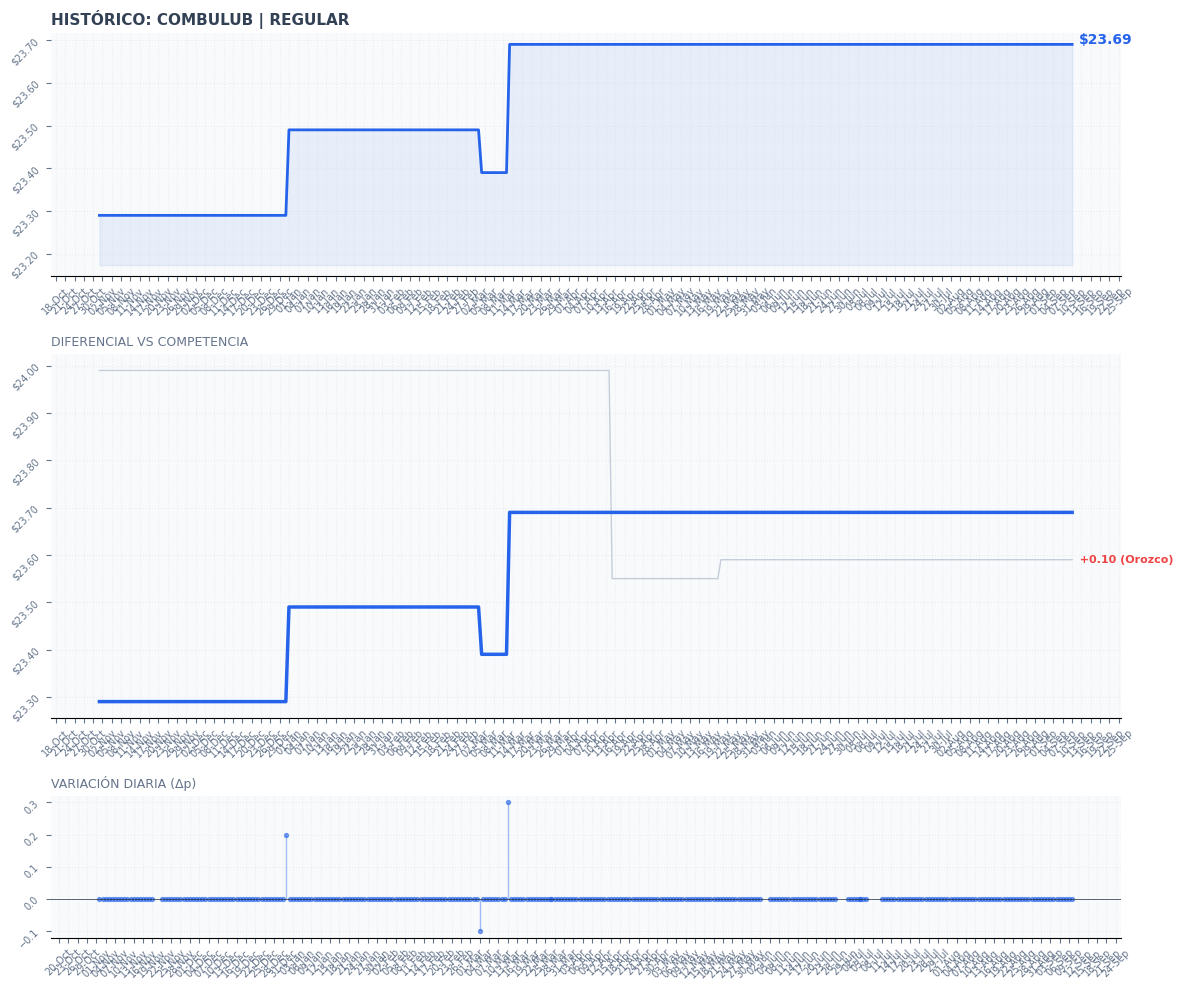

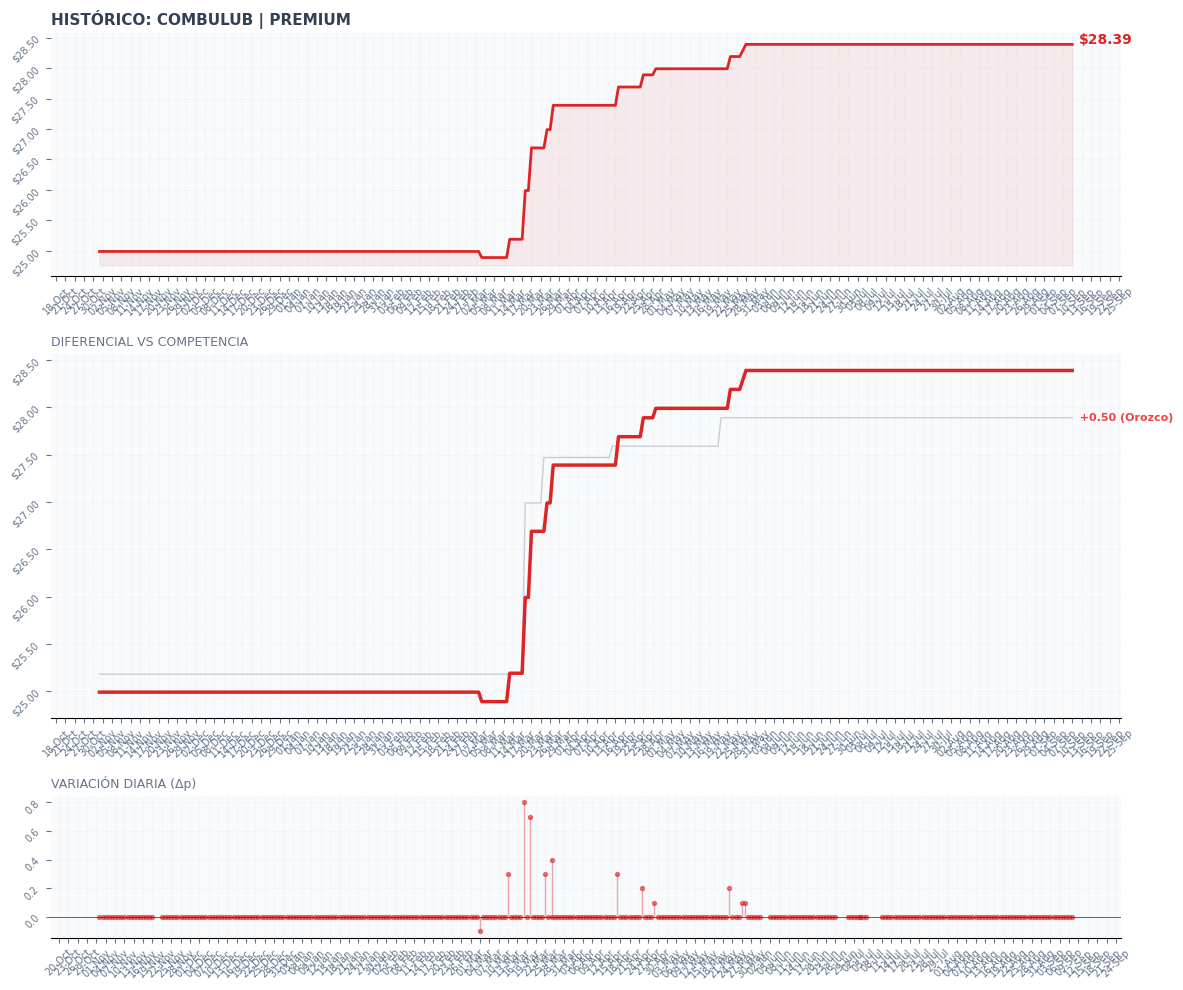

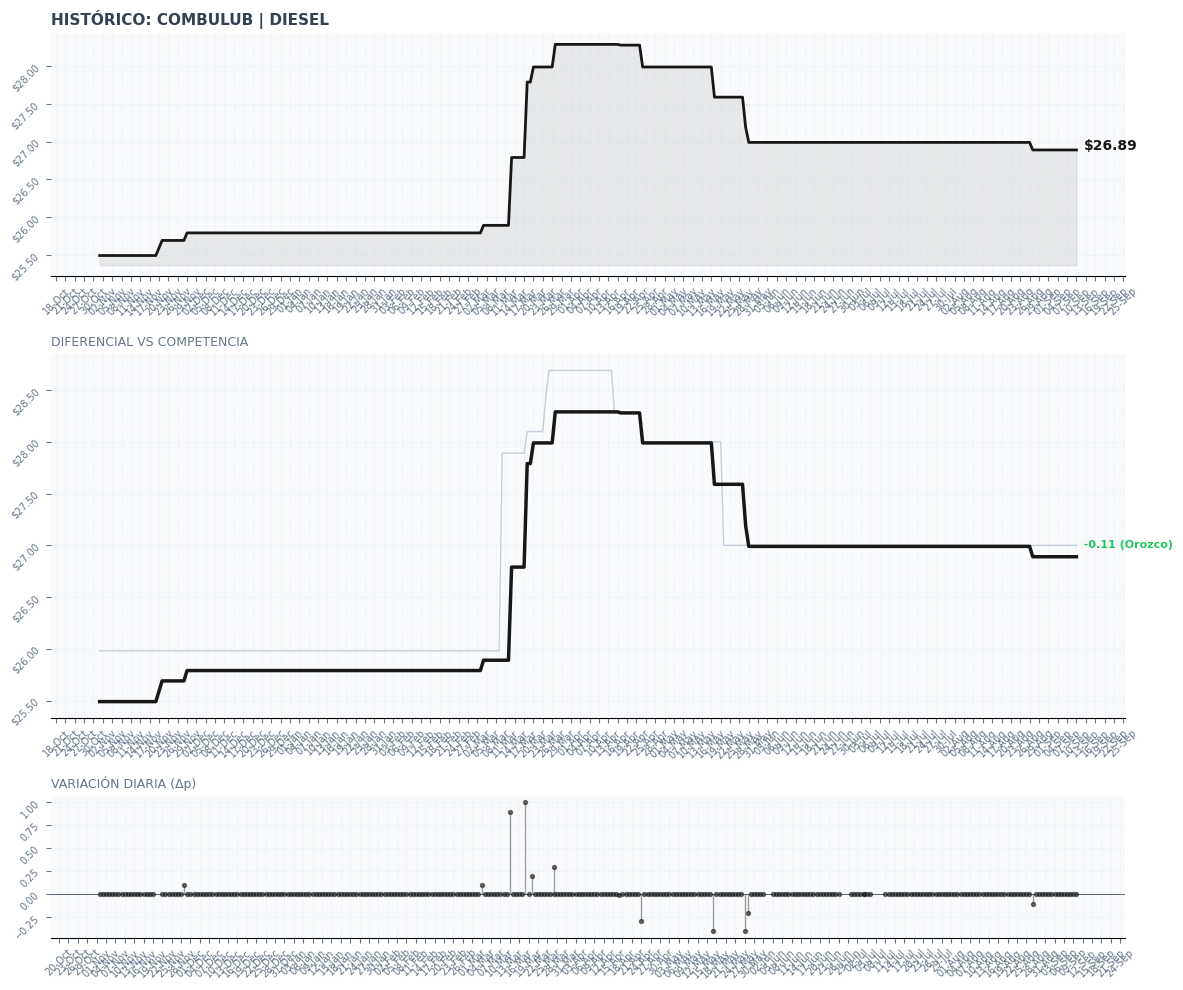

In [16]:
a = 'COMBULUB'
analizar_edgeworth_pro(DB, a, ESTACIONES)

In [15]:
correlacion_desfase(DB,a, ESTACIONES, max_lag=2)

,Gasolina,Competidor,Lag_dias,Correlacion
0,Regular,NR Combustibles,-2,-0.0000
1,Regular,NR Combustibles,-1,0.5905
2,Regular,NR Combustibles,0,0.0000
3,Regular,Valero Jorobas,-2,-0.0021
4,Regular,Valero Jorobas,-1,0.6681
5,Regular,Valero Jorobas,0,0.2213
6,Premium,NR Combustibles,-2,-0.0161
7,Premium,NR Combustibles,-1,-0.0025
8,Premium,NR Combustibles,0,0.0112
9,Premium,Valero Jorobas,-2,-0.0172


In [16]:
import pandas as pd
import numpy as np
from datetime import datetime

# Asegurar formato fecha
DB["Fecha"] = pd.to_datetime(DB["Fecha"])

# Obtener permisos de tus estaciones
mis_permisos = list(ESTACIONES.keys())

# Filtrar solo tus estaciones
db_mias = DB[DB["Permiso_CRE"].isin(mis_permisos)].copy()

# Ordenar por estación y fecha
db_mias = db_mias.sort_values(["Permiso_CRE", "Fecha"])

# Detectar cambios por combustible
for col in ["Regular", "Premium", "Diesel"]:
    db_mias[f"cambio_{col}"] = (
        db_mias.groupby("Permiso_CRE")[col]
        .diff()
        .fillna(0) != 0
    )

# Detectar si hubo cambio en cualquiera
db_mias["hubo_cambio"] = (
    db_mias[["cambio_Regular", "cambio_Premium", "cambio_Diesel"]]
    .any(axis=1)
)

# Obtener última fecha de cambio por estación
ultimo_cambio = (
    db_mias[db_mias["hubo_cambio"]]
    .groupby("Permiso_CRE")["Fecha"]
    .max()
    .reset_index()
)

ultimo_cambio.columns = ["Permiso_CRE", "Ultima_fecha_cambio"]

# Agregar alias
map_alias = {k: v["alias"] for k, v in ESTACIONES.items()}
ultimo_cambio["Estacion"] = ultimo_cambio["Permiso_CRE"].map(map_alias)

# Calcular días desde último cambio
hoy = pd.Timestamp.today().normalize()
ultimo_cambio["Dias_desde_ultimo_cambio"] = (
    (hoy - ultimo_cambio["Ultima_fecha_cambio"]).dt.days
)

# Orden final
resultado = ultimo_cambio[[
    "Estacion",
    "Permiso_CRE",
    "Ultima_fecha_cambio",
    "Dias_desde_ultimo_cambio"
]]

# Guardar Excel en tu carpeta actual
resultado.to_excel("ultimo_cambio_precios.xlsx", index=False)

print("Archivo guardado como: ultimo_cambio_precios.xlsx")

Archivo guardado como: ultimo_cambio_precios.xlsx


# ANALISIS RÁPIDOS

In [17]:
def cambios_recientes_competidores(DB, ESTACIONES, dias=5):

    import pandas as pd

    df = DB.copy()
    df["Fecha"] = pd.to_datetime(df["Fecha"])

    gasolinas = ["Regular","Premium","Diesel"]

    resultados = []

    # ordenar base
    df = df.sort_values(["Permiso_CRE","Fecha"])

    # calcular cambios de precio
    for g in gasolinas:
        df[f"delta_{g}"] = df.groupby("Permiso_CRE")[g].diff()

    hoy = df["Fecha"].max()
    limite = hoy - pd.Timedelta(days=dias)

    for permiso_base, info in ESTACIONES.items():

        alias_base = info["alias"]

        # precio actual de mi estación
        fila_base = (
            df[df["Permiso_CRE"] == permiso_base]
            .sort_values("Fecha")
            .tail(1)
        )

        if fila_base.empty:
            continue

        for permiso_comp, alias_comp in info["competidores"].items():

            datos_comp = df[df["Permiso_CRE"] == permiso_comp].copy()

            if datos_comp.empty:
                continue

            for g in gasolinas:

                cambios = datos_comp[
                    (datos_comp[f"delta_{g}"] != 0) &
                    (~datos_comp[f"delta_{g}"].isna()) &
                    (datos_comp["Fecha"] >= limite)
                ]

                if cambios.empty:
                    continue

                cambio_reciente = cambios.sort_values("Fecha").tail(1).iloc[0]

                resultados.append({
                    "Mi_estacion": alias_base,
                    "Competidor": alias_comp,
                    "Gasolina": g,
                    "Fecha_cambio": cambio_reciente["Fecha"],
                    "Cambio": cambio_reciente[f"delta_{g}"],
                    "Precio_competidor": cambio_reciente[g],
                    "Mi_precio_actual": fila_base[g].values[0]
                })

    return pd.DataFrame(resultados)

In [18]:
tabla_cambios = cambios_recientes_competidores(DB, ESTACIONES, dias=5)
tabla_cambios

,Mi_estacion,Competidor,Gasolina,Fecha_cambio,Cambio,Precio_competidor,Mi_precio_actual
0,ATB,Porba,Regular,2026-03-06,-0.2000,22.4900,23.5900
1,ATB,Nuevo Siglo,Regular,2026-03-04,-0.0700,22.5300,23.5900
2,ATB,Nuevo Siglo,Premium,2026-03-04,-0.0300,24.3700,25.0500
3,ATB,Nuevo Siglo,Diesel,2026-03-04,0.0500,24.8000,25.7500
4,AVE_FENIX,Azulita,Regular,2026-03-06,0.5000,23.4900,23.3400
5,AVE_FENIX,Azulita,Diesel,2026-03-06,0.5000,26.4900,25.7900
6,IXTAZACUALA,Servifacil,Diesel,2026-03-06,-0.1000,26.4900,25.9900
7,TH,Cupula,Premium,2026-03-04,0.1000,25.4800,25.0400
